In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml # 读取数据
from sklearn.model_selection import train_test_split # 划分训练集和测试集

In [2]:
# 下载数据集
boston = fetch_openml(name="boston", version=1, as_frame=False)

In [3]:
# 查看数据集，因为没有把他变成Frame格式，所以是json格式
boston

{'data': array([[0.00632, 18.0, 2.31, ..., 15.3, 396.9, 4.98],
        [0.02731, 0.0, 7.07, ..., 17.8, 396.9, 9.14],
        [0.02729, 0.0, 7.07, ..., 17.8, 392.83, 4.03],
        ...,
        [0.06076, 0.0, 11.93, ..., 21.0, 396.9, 5.64],
        [0.10959, 0.0, 11.93, ..., 21.0, 393.45, 6.48],
        [0.04741, 0.0, 11.93, ..., 21.0, 396.9, 7.88]],
       shape=(506, 13), dtype=object),
 'target': array([24. , 21.6, 34.7, 33.4, 36.2, 28.7, 22.9, 27.1, 16.5, 18.9, 15. ,
        18.9, 21.7, 20.4, 18.2, 19.9, 23.1, 17.5, 20.2, 18.2, 13.6, 19.6,
        15.2, 14.5, 15.6, 13.9, 16.6, 14.8, 18.4, 21. , 12.7, 14.5, 13.2,
        13.1, 13.5, 18.9, 20. , 21. , 24.7, 30.8, 34.9, 26.6, 25.3, 24.7,
        21.2, 19.3, 20. , 16.6, 14.4, 19.4, 19.7, 20.5, 25. , 23.4, 18.9,
        35.4, 24.7, 31.6, 23.3, 19.6, 18.7, 16. , 22.2, 25. , 33. , 23.5,
        19.4, 22. , 17.4, 20.9, 24.2, 21.7, 22.8, 23.4, 24.1, 21.4, 20. ,
        20.8, 21.2, 20.3, 28. , 23.9, 24.8, 22.9, 23.9, 26.6, 22.5, 22.2,
       

In [4]:
X = boston.data
X = X.astype(np.float64)
y = boston.target
y = y.astype(np.float64)

In [5]:
X

array([[6.3200e-03, 1.8000e+01, 2.3100e+00, ..., 1.5300e+01, 3.9690e+02,
        4.9800e+00],
       [2.7310e-02, 0.0000e+00, 7.0700e+00, ..., 1.7800e+01, 3.9690e+02,
        9.1400e+00],
       [2.7290e-02, 0.0000e+00, 7.0700e+00, ..., 1.7800e+01, 3.9283e+02,
        4.0300e+00],
       ...,
       [6.0760e-02, 0.0000e+00, 1.1930e+01, ..., 2.1000e+01, 3.9690e+02,
        5.6400e+00],
       [1.0959e-01, 0.0000e+00, 1.1930e+01, ..., 2.1000e+01, 3.9345e+02,
        6.4800e+00],
       [4.7410e-02, 0.0000e+00, 1.1930e+01, ..., 2.1000e+01, 3.9690e+02,
        7.8800e+00]], shape=(506, 13))

In [6]:
# 506条数，13个特征
X.shape

(506, 13)

In [7]:
y

array([24. , 21.6, 34.7, 33.4, 36.2, 28.7, 22.9, 27.1, 16.5, 18.9, 15. ,
       18.9, 21.7, 20.4, 18.2, 19.9, 23.1, 17.5, 20.2, 18.2, 13.6, 19.6,
       15.2, 14.5, 15.6, 13.9, 16.6, 14.8, 18.4, 21. , 12.7, 14.5, 13.2,
       13.1, 13.5, 18.9, 20. , 21. , 24.7, 30.8, 34.9, 26.6, 25.3, 24.7,
       21.2, 19.3, 20. , 16.6, 14.4, 19.4, 19.7, 20.5, 25. , 23.4, 18.9,
       35.4, 24.7, 31.6, 23.3, 19.6, 18.7, 16. , 22.2, 25. , 33. , 23.5,
       19.4, 22. , 17.4, 20.9, 24.2, 21.7, 22.8, 23.4, 24.1, 21.4, 20. ,
       20.8, 21.2, 20.3, 28. , 23.9, 24.8, 22.9, 23.9, 26.6, 22.5, 22.2,
       23.6, 28.7, 22.6, 22. , 22.9, 25. , 20.6, 28.4, 21.4, 38.7, 43.8,
       33.2, 27.5, 26.5, 18.6, 19.3, 20.1, 19.5, 19.5, 20.4, 19.8, 19.4,
       21.7, 22.8, 18.8, 18.7, 18.5, 18.3, 21.2, 19.2, 20.4, 19.3, 22. ,
       20.3, 20.5, 17.3, 18.8, 21.4, 15.7, 16.2, 18. , 14.3, 19.2, 19.6,
       23. , 18.4, 15.6, 18.1, 17.4, 17.1, 13.3, 17.8, 14. , 14.4, 13.4,
       15.6, 11.8, 13.8, 15.6, 14.6, 17.8, 15.4, 21

In [8]:
# 506条样本的房价，预测值
y.shape

(506,)

In [9]:
# 划分训练集和测试集，X_train和y_train一起用，剩下的一起用
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [10]:
# 每个特征的尺度都不同，需要进行数据预处理
X_train[:5]

array([[1.50234e+01, 0.00000e+00, 1.81000e+01, 0.00000e+00, 6.14000e-01,
        5.30400e+00, 9.73000e+01, 2.10070e+00, 2.40000e+01, 6.66000e+02,
        2.02000e+01, 3.49480e+02, 2.49100e+01],
       [6.27390e-01, 0.00000e+00, 8.14000e+00, 0.00000e+00, 5.38000e-01,
        5.83400e+00, 5.65000e+01, 4.49860e+00, 4.00000e+00, 3.07000e+02,
        2.10000e+01, 3.95620e+02, 8.47000e+00],
       [3.46600e-02, 3.50000e+01, 6.06000e+00, 0.00000e+00, 4.37900e-01,
        6.03100e+00, 2.33000e+01, 6.64070e+00, 1.00000e+00, 3.04000e+02,
        1.69000e+01, 3.62250e+02, 7.83000e+00],
       [7.05042e+00, 0.00000e+00, 1.81000e+01, 0.00000e+00, 6.14000e-01,
        6.10300e+00, 8.51000e+01, 2.02180e+00, 2.40000e+01, 6.66000e+02,
        2.02000e+01, 2.52000e+00, 2.32900e+01],
       [7.25800e-01, 0.00000e+00, 8.14000e+00, 0.00000e+00, 5.38000e-01,
        5.72700e+00, 6.95000e+01, 3.79650e+00, 4.00000e+00, 3.07000e+02,
        2.10000e+01, 3.90950e+02, 1.12800e+01]])

In [11]:
# 手写一个标准化类
class StandarScaler:
    def __init__(self):
        self.mean = None # 均值
        self.std = None # 标准差
    
    def fit(self, X):
        self.mean = np.mean(X, axis=0)  # 按列取平均值，得到一个长度为特征数量的向量，表示这一列这个特征的平均值
        self.std = np.std(X, axis=0)

    # 数组维度不一样也可以计算的原因是广播机制，会扩展成相同维度的数组
    def transform(self, X):
        return (X - self.mean) / self.std   # 计算出一个标准化后的新值

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

In [12]:
# 初始化一个标准化器
scaler = StandarScaler()

In [13]:
# 这个是对训练集，学习训练集的平均值和标准差，然后标准化
X_train_scaled = scaler.fit_transform(X_train)
# 但是我们不能对测试集也去学他的均值和标准差，为了保证变化相同，我们用训练集的来标准化测试集
X_test_scaled = scaler.transform(X_test)

In [14]:
# 现在有了标准化后的训练集，和用同一套规则标准化的测试集，以及他们分别的标签
X_train_scaled

array([[ 1.28770177, -0.50032012,  1.03323679, ...,  0.84534281,
        -0.07433689,  1.75350503],
       [-0.33638447, -0.50032012, -0.41315956, ...,  1.20474139,
         0.4301838 , -0.5614742 ],
       [-0.40325332,  1.01327135, -0.71521823, ..., -0.63717631,
         0.06529747, -0.65159505],
       ...,
       [-0.40547014,  2.95931752, -1.30336132, ..., -0.59225149,
         0.37901005, -0.91069248],
       [ 0.85189733, -0.50032012,  1.03323679, ...,  0.84534281,
        -2.69458597,  1.52257036],
       [-0.38135592, -0.50032012, -0.35216694, ...,  1.15981657,
        -3.12158061, -0.25731635]], shape=(404, 13))

In [15]:
X_train_scaled.shape

(404, 13)

In [16]:
y_train

array([12. , 19.9, 19.4, 13.4, 18.2, 24.6, 21.1, 24.7,  8.7, 27.5, 20.7,
       36.2, 31.6, 11.7, 39.8, 13.9, 21.8, 23.7, 17.6, 24.4,  8.8, 19.2,
       25.3, 20.4, 23.1, 37.9, 15.6, 45.4, 15.7, 22.6, 14.5, 18.7, 17.8,
       16.1, 20.6, 31.6, 29.1, 15.6, 17.5, 22.5, 19.4, 19.3,  8.5, 20.6,
       17. , 17.1, 14.5, 50. , 14.3, 12.6, 28.7, 21.2, 19.3, 23.1, 19.1,
       25. , 33.4,  5. , 29.6, 18.7, 21.7, 23.1, 22.8, 21. , 48.8, 14.6,
       16.6, 27.1, 20.1, 19.8, 21. , 41.3, 23.2, 20.4, 18.5, 29.4, 36.4,
       24.4, 11.8, 13.8, 12.3, 17.8, 33.1, 26.7, 13.4, 14.4, 50. , 22. ,
       19.9, 23.8, 17.5, 12.7,  5.6, 31.1, 26.2, 19.4, 16.7, 13.8, 22.9,
       15.3, 27.5, 36.1, 22.9, 24.5, 25. , 50. , 34.9, 31.7, 24.1, 22.1,
       14.1, 42.8, 19.3, 32.2, 26.4, 21.8, 21.7,  8.3, 46.7, 43.1, 31.5,
       10.5, 16.7, 20. , 33.3, 17.8, 50. , 20.5, 23.2, 13.1, 19.6, 22.8,
       28.7, 30.7, 22.9, 21.9, 23.9, 32.7, 24.3, 21.5, 24.6,  8.5, 26.4,
       23.1, 15. ,  8.8, 19.3, 23.9, 24.7, 19.8, 23

In [17]:
y_train.shape

(404,)

In [31]:
# 基于一阶梯度下降（Gradient Descent,GD）的线性回归模型
class LinearRegressionGD:
    def __init__(self, n_features, learning_rate=0.01):
        self.w = np.random.randn(n_features, 1)
        self.b = 0.0
        self.learning_rate = learning_rate

    def forward(self, X):
        # 这个@是矩阵乘法，和*不相同，后者是逐元素乘法
        y_pred = X @ self.w + self.b
        return y_pred

    # MSE均方误差，不一定只能用这个，但是线性模型一般都会用这个
    def loss(self, y_pred, y_true):
        error = y_pred - y_true
        return np.mean(error ** 2)

    def gradient(self, X, y_true):
        n = X.shape[0]
        y_pred = self.forward(X)
        error = y_pred - y_true

        # 线性回归的更新公式，T表示矩阵的转置，算出梯度
        grad_w = (2 / n) * (X.T @ error)
        grad_b = (2 / n) * np.sum(error)

        return grad_w, grad_b

    # 梯度更新的函数，因为我们要让loss变小，所以求导后如果是正数，说明这个参数变大，loss也变大，所以我们要让参数变小
    # 如果求导是负数，说明这个参数变大，loss会变小，因此不管怎么样，我们都是负号
    def update(self, grad_w, grad_b):
        self.w -= self.learning_rate * grad_w
        self.b -= self.learning_rate * grad_b

    def train(self, X, y, epochs=1000, verbose=False):
        # 这个很重要，相当于是避免广播让他变成样本数，1维度的数组
        if y.ndim == 1:
            y = y.reshape(-1, 1)
        losses = []

        for epoch in range(epochs):
            y_pred = self.forward(X)

            loss_value = self.loss(y_pred, y)
            losses.append(loss_value)

            grad_w, grad_b = self.gradient(X, y)

            self.update(grad_w, grad_b)

            if verbose and epoch % 100 == 0:
                print(f"Epoch {epoch}, Loss: {loss_value:.4f}")

        return losses

    # 留给使用模型去预测的人用的
    def predict(self, X):
        return self.forward(X)

In [32]:
# 动量优化器的线性回归模型
class LinearRegressionMomentum:
    def __init__(self, n_features, learning_rate=0.01, beta=0.9):
        self.w = np.random.randn(n_features, 1)
        self.b = 0.0
        
        self.learning_rate = learning_rate
        self.beta = beta

        # 每个参数都有的动量
        self.v_w = np.zeros_like(self.w)
        self.v_b = 0.0

    def forward(self, X):
        return X @ self.w + self.b

    def loss(self, y_pred, y_true):
        error = y_pred - y_true
        return np.mean(error ** 2)

    # 确定了模型（线性回归）和损失（MSE）之后，参数的梯度计算公式也确定了
    # 使用不同的优化器，是在通过不同的方式用这个梯度
    def gradient(self, X, y_true):
        n = X.shape[0]
        y_pred = self.forward(X)
        error = y_pred - y_true

        grad_w = (2 / n) * (X.T @ error)
        grad_b = (2 / n) * np.sum(error)

        return grad_w, grad_b

    def update(self, grad_w, grad_b):
        self.v_w = self.beta * self.v_w + (1 - self.beta) * grad_w
        self.v_b = self.beta * self.v_b + (1 - self.beta) * grad_b

        self.w = self.w - self.learning_rate * self.v_w
        self.b = self.b - self.learning_rate * self.v_b

    def train(self, X, y, epochs=1000, verbose=False):
        if y.ndim == 1:
            y = y.reshape(-1, 1)

        losses = []

        for epoch in range(epochs):
            y_pred = self.forward(X)
            loss_value = self.loss(y_pred, y)
            losses.append(loss_value)

            grad_w, grad_b = self.gradient(X, y)
            self.update(grad_w, grad_b)

            if verbose and epoch % 100 == 0:
                print(f"Epoch {epoch}, Loss: {loss_value:.6f}")

        return losses

    def predict(self, X):
        return self.forward(X)


In [38]:
# AdaGrad优化器的线性回归模型：不同参数不同学习率
class LinearRegressionAdaGrad:
    def __init__(self, n_features, learning_rate=0.01, eps=1e-8):
        self.w = np.random.randn(n_features, 1)
        self.b = 0.0

        self.learning_rate = learning_rate
        self.eps = eps

        # 每个参数的累计梯度
        self.G_w = np.zeros_like(self.w)
        self.G_b = 0.0

    def forward(self, X):
        return X @ self.w + self.b

    def loss(self, y_pred, y_true):
        error = y_pred - y_true
        return np.mean(error ** 2)

    def gradient(self, X, y_true):
        n = X.shape[0]
        y_pred = self.forward(X)
        error = y_pred - y_true

        grad_w = (2 / n) * (X.T @ error)
        grad_b = (2 / n) * np.sum(error)

        return grad_w, grad_b

    def update(self, grad_w, grad_b):
        self.G_w += grad_w ** 2
        self.G_b += grad_b ** 2

        self.w -= self.learning_rate / (np.sqrt(self.G_w) + self.eps) * grad_w
        self.b -= self.learning_rate / (np.sqrt(self.G_b) + self.eps) * grad_b
    
    def train(self, X, y, epochs=1000, verbose=False):
        if y.ndim == 1:
            y = y.reshape(-1, 1)

        losses = []

        for epoch in range(epochs):
            y_pred = self.forward(X)
            loss_value = self.loss(y_pred, y)
            losses.append(loss_value)

            grad_w, grad_b = self.gradient(X, y)
            self.update(grad_w, grad_b)

            if verbose and epoch % 100 == 0:
                print(f"Epoch {epoch}, Loss: {loss_value:.6f}")

        return losses

    def predict(self, X):
        return self.forward(X)

In [39]:
# Adam的线性回归模型
class LinearRegressionAdam:
    def __init__(self, n_features, learning_rate=0.01,
                 beta1=0.9, beta2=0.999, eps=1e-8):
        # 模型参数
        self.w = np.random.randn(n_features, 1)
        self.b = 0.0

        # 超参数
        self.learning_rate = learning_rate
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps

        # 一阶矩（Momentum）
        self.m_w = np.zeros_like(self.w)
        self.m_b = 0.0

        # 二阶矩（RMS）
        self.v_w = np.zeros_like(self.w)
        self.v_b = 0.0

        # 时间步
        self.t = 0

    def forward(self, X):
        return X @ self.w + self.b

    def loss(self, y_pred, y_true):
        error = y_pred - y_true
        return np.mean(error ** 2)

    def gradient(self, X, y_true):
        n = X.shape[0]
        y_pred = self.forward(X)
        error = y_pred - y_true

        grad_w = (2 / n) * (X.T @ error)
        grad_b = (2 / n) * np.sum(error)

        return grad_w, grad_b

    def update(self, grad_w, grad_b):
        # 时间步 +1
        self.t += 1

        # 一阶矩更新
        self.m_w = self.beta1 * self.m_w + (1 - self.beta1) * grad_w
        self.m_b = self.beta1 * self.m_b + (1 - self.beta1) * grad_b

        # 二阶矩更新
        self.v_w = self.beta2 * self.v_w + (1 - self.beta2) * (grad_w ** 2)
        self.v_b = self.beta2 * self.v_b + (1 - self.beta2) * (grad_b ** 2)

        # 偏置修正
        m_w_hat = self.m_w / (1 - self.beta1 ** self.t)
        m_b_hat = self.m_b / (1 - self.beta1 ** self.t)

        v_w_hat = self.v_w / (1 - self.beta2 ** self.t)
        v_b_hat = self.v_b / (1 - self.beta2 ** self.t)

        # 参数更新
        self.w -= self.learning_rate * m_w_hat / (np.sqrt(v_w_hat) + self.eps)
        self.b -= self.learning_rate * m_b_hat / (np.sqrt(v_b_hat) + self.eps)

    def train(self, X, y, epochs=1000, verbose=False):
        if y.ndim == 1:
            y = y.reshape(-1, 1)

        losses = []

        for epoch in range(epochs):
            y_pred = self.forward(X)
            loss_value = self.loss(y_pred, y)
            losses.append(loss_value)

            grad_w, grad_b = self.gradient(X, y)
            self.update(grad_w, grad_b)

            if verbose and epoch % 100 == 0:
                print(f"Epoch {epoch}, Loss: {loss_value:.6f}")

        return losses

    def predict(self, X):
        return self.forward(X)

In [63]:
# 实验一：不同优化算法的收敛速度对比实验
# 就是说，其他条件一样的情况下，模型的收敛速度会不会根据优化算法的选择有不同
# 统一实验参数
epochs = 10000
learning_rate = 0.01
n_features = X_train_scaled.shape[1]

In [64]:
model_gd = LinearRegressionGD(
    n_features=n_features,
    learning_rate=learning_rate
)

model_momentum = LinearRegressionMomentum(
    n_features=n_features,
    learning_rate=learning_rate,
    beta=0.9
)

model_adagrad = LinearRegressionAdaGrad(
    n_features=n_features,
    learning_rate=learning_rate
)

model_adam = LinearRegressionAdam(
    n_features=n_features,
    learning_rate=learning_rate
)


In [65]:
loss_gd = model_gd.train(
    X_train_scaled, y_train, epochs=epochs
)

loss_momentum = model_momentum.train(
    X_train_scaled, y_train, epochs=epochs
)

loss_adagrad = model_adagrad.train(
    X_train_scaled, y_train, epochs=epochs
)

loss_adam = model_adam.train(
    X_train_scaled, y_train, epochs=epochs
)


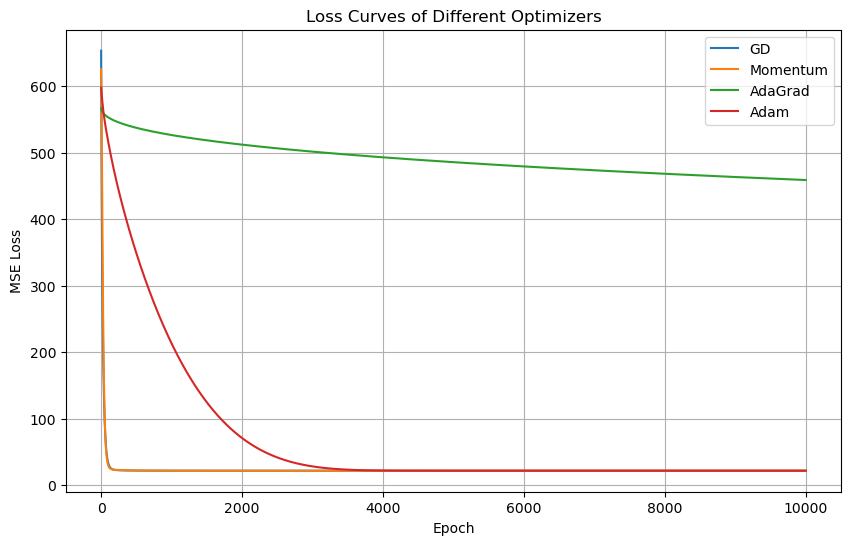

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(loss_gd, label="GD")
plt.plot(loss_momentum, label="Momentum")
plt.plot(loss_adagrad, label="AdaGrad")
plt.plot(loss_adam, label="Adam")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Loss Curves of Different Optimizers")
plt.legend()
plt.grid(True)
plt.show()


In [94]:
# 实验二：不同学习率下不同优化算法的收敛稳定性对比
y_train_vec = y_train.reshape(-1, 1)
y_test_vec = y_test.reshape(-1, 1)

In [95]:
epochs = 2000
learning_rates = [0.001, 0.01, 0.1]

In [96]:
def run_all_optimizers(X, y, lr, epochs):
    results = {}

    # GD
    model_gd = LinearRegressionGD(
        n_features=X.shape[1],
        learning_rate=lr
    )
    results["GD"] = model_gd.train(X, y, epochs=epochs)

    # Momentum
    model_momentum = LinearRegressionMomentum(
        n_features=X.shape[1],
        learning_rate=lr,
        beta=0.9
    )
    results["Momentum"] = model_momentum.train(X, y, epochs=epochs)

    # AdaGrad
    model_adagrad = LinearRegressionAdaGrad(
        n_features=X.shape[1],
        learning_rate=lr
    )
    results["AdaGrad"] = model_adagrad.train(X, y, epochs=epochs)

    # Adam
    model_adam = LinearRegressionAdam(
        n_features=X.shape[1],
        learning_rate=lr
    )
    results["Adam"] = model_adam.train(X, y, epochs=epochs)

    return results

In [97]:
all_results = {}

for lr in learning_rates:
    print(f"Running experiments for learning rate = {lr}")
    all_results[lr] = run_all_optimizers(
        X_train_scaled,
        y_train_vec,
        lr=lr,
        epochs=epochs
    )


Running experiments for learning rate = 0.001
Running experiments for learning rate = 0.01
Running experiments for learning rate = 0.1


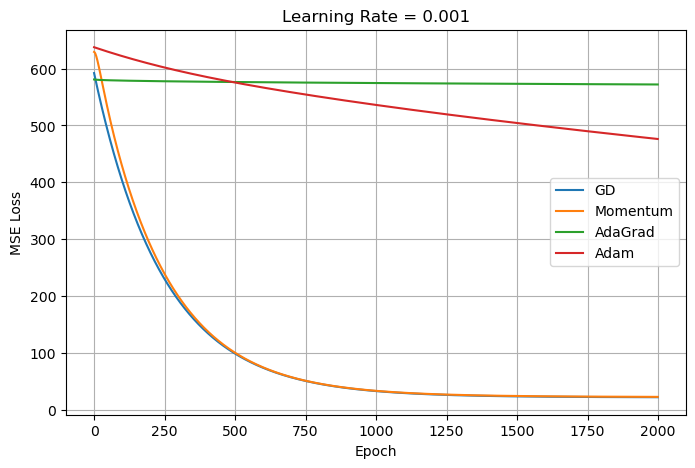

In [98]:
plt.figure(figsize=(8, 5))

for name, losses in all_results[0.001].items():
    plt.plot(losses, label=name)

plt.title("Learning Rate = 0.001")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.show()


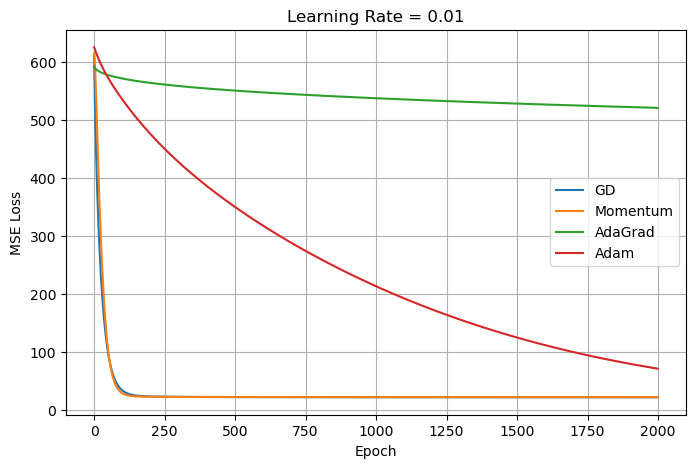

In [99]:
plt.figure(figsize=(8, 5))

for name, losses in all_results[0.01].items():
    plt.plot(losses, label=name)

plt.title("Learning Rate = 0.01")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.show()


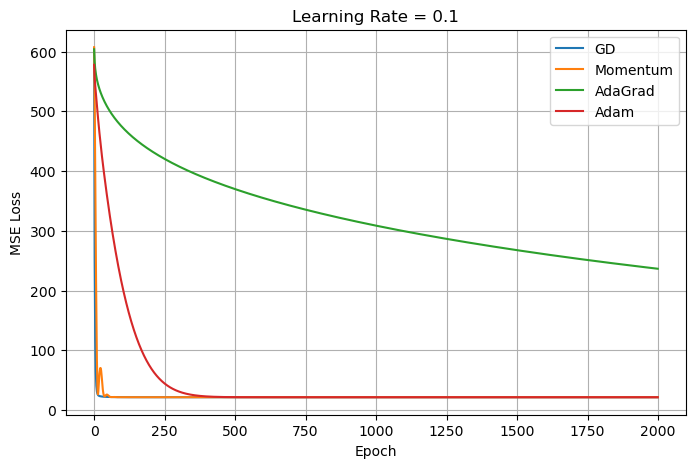

In [100]:
plt.figure(figsize=(8, 5))

for name, losses in all_results[0.1].items():
    plt.plot(losses, label=name)

plt.title("Learning Rate = 0.1")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.show()


In [101]:
# 实验三：不同优化算法泛化能力的对比
epochs = 2000
learning_rate = 0.01

In [102]:
# GD
model_gd = LinearRegressionGD(
    n_features=X_train_scaled.shape[1],
    learning_rate=learning_rate
)
model_gd.train(X_train_scaled, y_train_vec, epochs=epochs)

# Momentum
model_momentum = LinearRegressionMomentum(
    n_features=X_train_scaled.shape[1],
    learning_rate=learning_rate,
    beta=0.9
)
model_momentum.train(X_train_scaled, y_train_vec, epochs=epochs)

# AdaGrad
model_adagrad = LinearRegressionAdaGrad(
    n_features=X_train_scaled.shape[1],
    learning_rate=learning_rate
)
model_adagrad.train(X_train_scaled, y_train_vec, epochs=epochs)

# Adam
model_adam = LinearRegressionAdam(
    n_features=X_train_scaled.shape[1],
    learning_rate=learning_rate
)
model_adam.train(X_train_scaled, y_train_vec, epochs=epochs)


[np.float64(592.2619281252444),
 np.float64(591.3793274479652),
 np.float64(590.503323794949),
 np.float64(589.6340235773074),
 np.float64(588.7714969174327),
 np.float64(587.9157726039233),
 np.float64(587.0668315479229),
 np.float64(586.2245990628119),
 np.float64(585.3889369413239),
 np.float64(584.5596371591535),
 np.float64(583.7364199464158),
 np.float64(582.9189393115768),
 np.float64(582.1067979670414),
 np.float64(581.2995706357152),
 np.float64(580.4968311429298),
 np.float64(579.6981769698693),
 np.float64(578.9032464684989),
 np.float64(578.1117274596651),
 np.float64(577.3233589067423),
 np.float64(576.5379284094572),
 np.float64(575.7552677960497),
 np.float64(574.9752481413055),
 np.float64(574.1977747808075),
 np.float64(573.4227824923605),
 np.float64(572.6502308768828),
 np.float64(571.8800999564293),
 np.float64(571.1123860263071),
 np.float64(570.3470978119032),
 np.float64(569.5842529798185),
 np.float64(568.8238750408226),
 np.float64(568.0659906652485),
 np.float

In [103]:
y_pred_gd = model_gd.predict(X_test_scaled)
y_pred_momentum = model_momentum.predict(X_test_scaled)
y_pred_adagrad = model_adagrad.predict(X_test_scaled)
y_pred_adam = model_adam.predict(X_test_scaled)

In [104]:
def mse(y_pred, y_true):
    return np.mean((y_pred - y_true) ** 2)

In [105]:
mse_results = {
    "GD": mse(y_pred_gd, y_test_vec),
    "Momentum": mse(y_pred_momentum, y_test_vec),
    "AdaGrad": mse(y_pred_adagrad, y_test_vec),
    "Adam": mse(y_pred_adam, y_test_vec)
}

for k, v in mse_results.items():
    print(f"{k} Test MSE: {v:.4f}")

GD Test MSE: 24.3539
Momentum Test MSE: 24.3705
AdaGrad Test MSE: 495.5807
Adam Test MSE: 76.7943


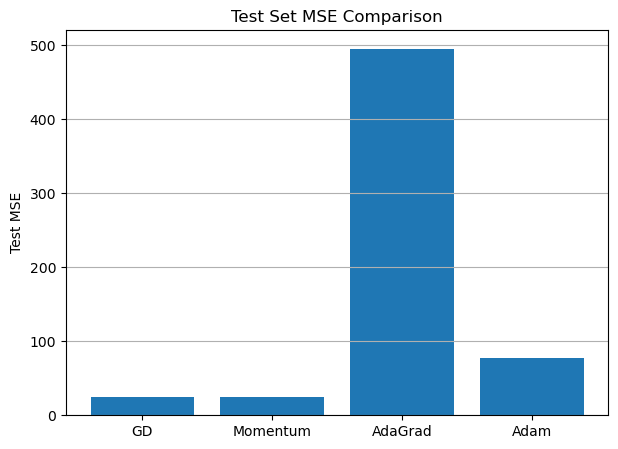

In [106]:
plt.figure(figsize=(7, 5))
plt.bar(mse_results.keys(), mse_results.values())
plt.ylabel("Test MSE")
plt.title("Test Set MSE Comparison")
plt.grid(axis="y")
plt.show()

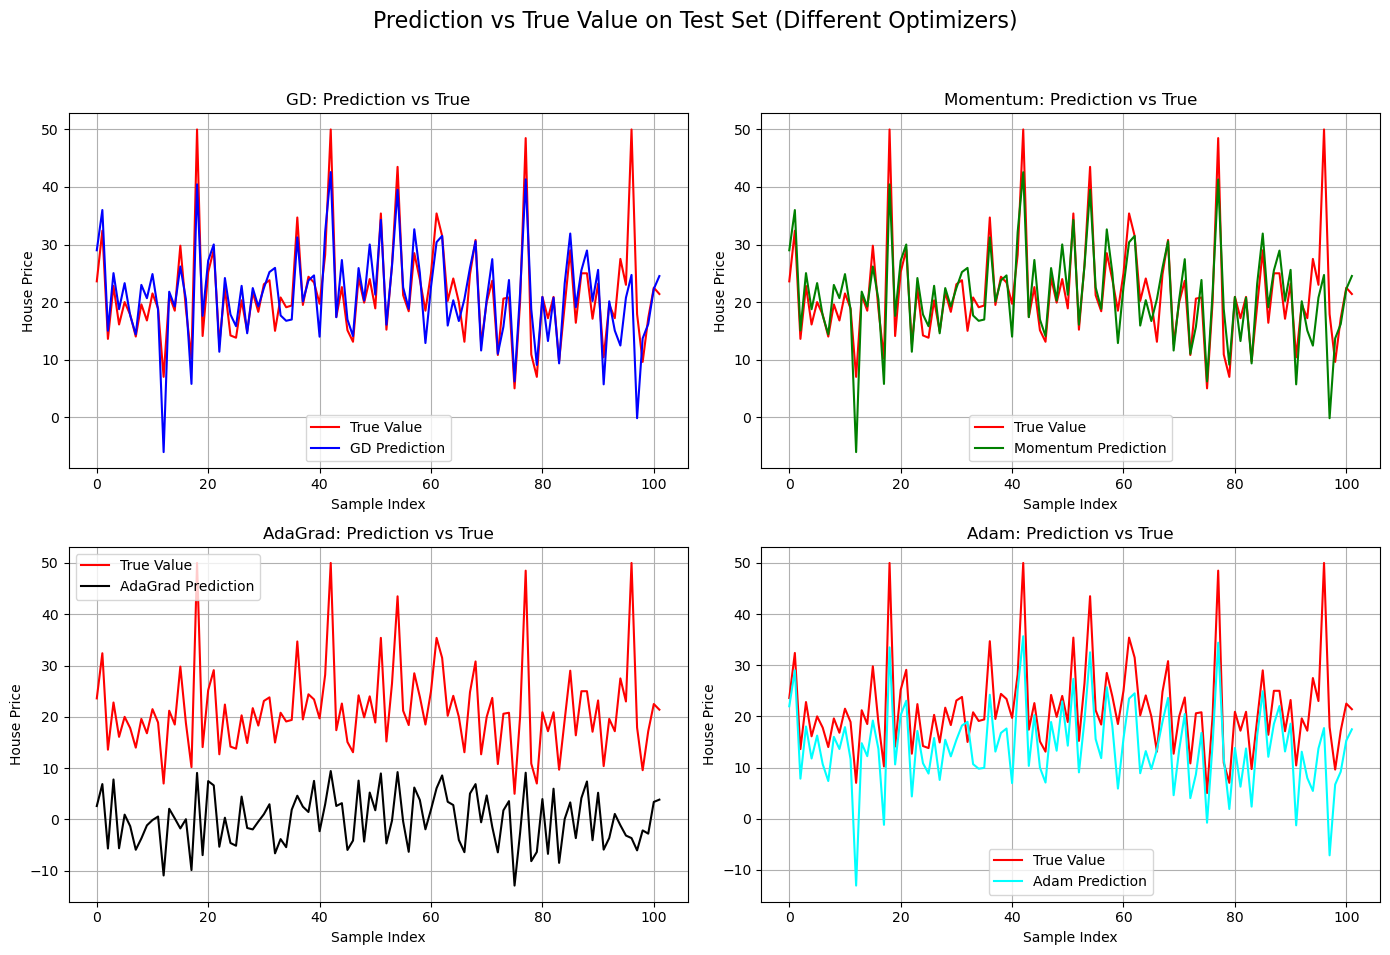

In [107]:
plt.figure(figsize=(14, 10))

# ====== 子图 1：GD ======
plt.subplot(2, 2, 1)
plt.plot(y_test_vec, label="True Value", color="red")
plt.plot(y_pred_gd, label="GD Prediction", color="blue")
plt.title("GD: Prediction vs True")
plt.xlabel("Sample Index")
plt.ylabel("House Price")
plt.legend()
plt.grid(True)

# ====== 子图 2：Momentum ======
plt.subplot(2, 2, 2)
plt.plot(y_test_vec, label="True Value", color="red")
plt.plot(y_pred_momentum, label="Momentum Prediction", color="green")
plt.title("Momentum: Prediction vs True")
plt.xlabel("Sample Index")
plt.ylabel("House Price")
plt.legend()
plt.grid(True)

# ====== 子图 3：AdaGrad ======
plt.subplot(2, 2, 3)
plt.plot(y_test_vec, label="True Value", color="red")
plt.plot(y_pred_adagrad, label="AdaGrad Prediction", color="black")
plt.title("AdaGrad: Prediction vs True")
plt.xlabel("Sample Index")
plt.ylabel("House Price")
plt.legend()
plt.grid(True)

# ====== 子图 4：Adam ======
plt.subplot(2, 2, 4)
plt.plot(y_test_vec, label="True Value", color="red")
plt.plot(y_pred_adam, label="Adam Prediction", color="cyan")
plt.title("Adam: Prediction vs True")
plt.xlabel("Sample Index")
plt.ylabel("House Price")
plt.legend()
plt.grid(True)

plt.suptitle("Prediction vs True Value on Test Set (Different Optimizers)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [110]:
# 实验四：线性模型的可解释性分析

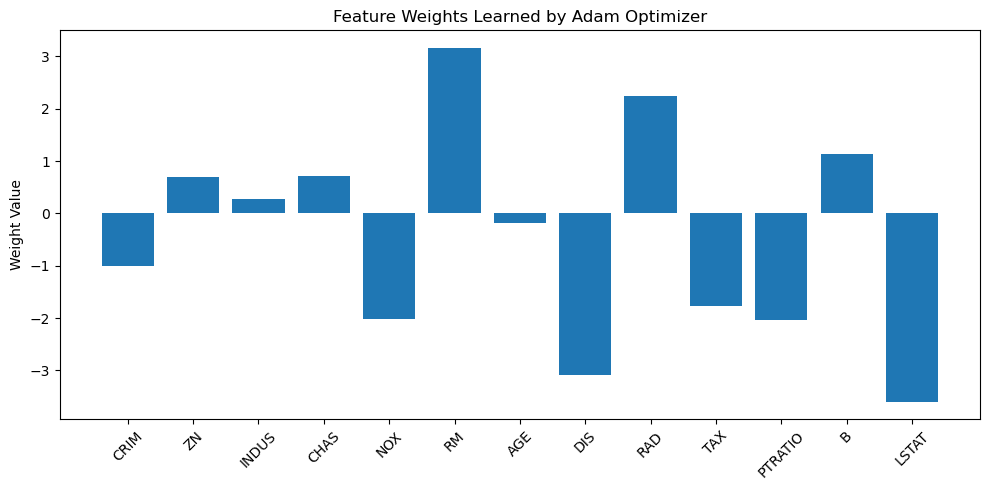

In [109]:
feature_names = boston.feature_names

weights = model_adam.w.flatten()

plt.figure(figsize=(10, 5))
plt.bar(feature_names, weights)
plt.xticks(rotation=45)
plt.ylabel("Weight Value")
plt.title("Feature Weights Learned by Adam Optimizer")
plt.tight_layout()
plt.show()
